# Problema 1 — El Colapso Silencioso de la Salud Pública
### ODS 3: Salud y Bienestar · Narrativa Visual con Plotly · HackODS 2026

> *"El sistema de salud pública de México no colapsó de golpe.  
> Colapsó en silencio, indicador por indicador, año tras año."*

---

**Fuente de datos:** INEGI — 333 indicadores ODS de México (1970–2026)  
**Indicadores ODS 3 analizados:** 37 de 42 con datos nacionales disponibles  
**Periodo de análisis:** 1990–2024

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Paleta de colores ─────────────────────────────────────────────────────────
COLOR_ALERTA   = '#E63946'
COLOR_MEJORA   = '#2DC653'
COLOR_NEUTRO   = '#457B9D'
COLOR_FONDO    = '#F8F9FA'
COLOR_LINEA    = '#1D3557'
COLOR_ACENTO   = '#F4A261'
COLOR_ODS3     = '#4C9F38'

# ── Cargar datos ──────────────────────────────────────────────────────────────
df = pd.read_csv('../data/consolidated/indicadores_largo.csv')

def get_serie(indicator_id):
    return df[df['indicator_id'] == indicator_id].sort_values('periodo').copy()

print('Datos cargados:', len(df), 'observaciones')
print('Indicadores ODS 3 con datos:', df[df['indicator_id'].str.startswith('3')]['indicator_id'].nunique())

Datos cargados: 3611 observaciones
Indicadores ODS 3 con datos: 37


---
## Resumen Ejecutivo — Las 4 Alarmas

Antes de entrar en detalle, estos son los **cuatro números que definen la crisis**.

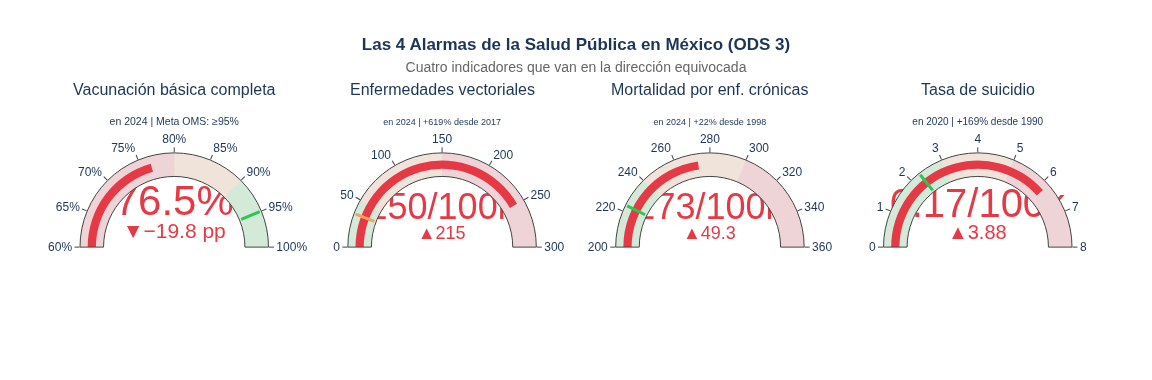

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 1 — Dashboard de KPIs: Las 4 Alarmas
# go.Indicator requiere specs type='indicator' en make_subplots
# ══════════════════════════════════════════════════════════════════════════════

fig_kpi = make_subplots(
    rows=1, cols=4,
    subplot_titles=[
        'Vacunación básica completa',
        'Enfermedades vectoriales',
        'Mortalidad por enf. crónicas',
        'Tasa de suicidio'
    ],
    specs=[[{'type': 'indicator'}, {'type': 'indicator'},
            {'type': 'indicator'}, {'type': 'indicator'}]],
    horizontal_spacing=0.08
)

# KPI 1 — Vacunación
fig_kpi.add_trace(go.Indicator(
    mode='number+delta+gauge',
    value=76.5,
    delta={'reference': 96.3, 'valueformat': '.1f', 'suffix': ' pp',
           'decreasing': {'color': COLOR_ALERTA}},
    number={'suffix': '%', 'valueformat': '.1f',
            'font': {'size': 42, 'color': COLOR_ALERTA}},
    gauge={
        'axis': {'range': [60, 100], 'ticksuffix': '%'},
        'bar': {'color': COLOR_ALERTA, 'thickness': 0.35},
        'bgcolor': '#F0F0F0',
        'steps': [
            {'range': [60, 80], 'color': 'rgba(230,57,70,0.15)'},
            {'range': [80, 90], 'color': 'rgba(244,162,97,0.15)'},
            {'range': [90, 100], 'color': 'rgba(44,198,83,0.15)'}
        ],
        'threshold': {'line': {'color': COLOR_MEJORA, 'width': 3}, 'value': 95}
    },
    title={'text': 'en 2024 | Meta OMS: ≥95%'}
), row=1, col=1)

# KPI 2 — Enf. Vectoriales
fig_kpi.add_trace(go.Indicator(
    mode='number+delta+gauge',
    value=249.9,
    delta={'reference': 34.8, 'valueformat': '.0f',
           'increasing': {'color': COLOR_ALERTA}},
    number={'suffix': '/100k', 'valueformat': '.0f',
            'font': {'size': 36, 'color': COLOR_ALERTA}},
    gauge={
        'axis': {'range': [0, 300]},
        'bar': {'color': COLOR_ALERTA, 'thickness': 0.35},
        'bgcolor': '#F0F0F0',
        'steps': [
            {'range': [0, 50], 'color': 'rgba(44,198,83,0.15)'},
            {'range': [50, 150], 'color': 'rgba(244,162,97,0.15)'},
            {'range': [150, 300], 'color': 'rgba(230,57,70,0.15)'}
        ],
        'threshold': {'line': {'color': COLOR_ACENTO, 'width': 3}, 'value': 34.8}
    },
    title={'text': 'en 2024 | +619% desde 2017'}
), row=1, col=2)

# KPI 3 — Mortalidad crónica
fig_kpi.add_trace(go.Indicator(
    mode='number+delta+gauge',
    value=272.9,
    delta={'reference': 223.6, 'valueformat': '.1f',
           'increasing': {'color': COLOR_ALERTA}},
    number={'suffix': '/100k', 'valueformat': '.0f',
            'font': {'size': 36, 'color': COLOR_ALERTA}},
    gauge={
        'axis': {'range': [200, 360]},
        'bar': {'color': COLOR_ALERTA, 'thickness': 0.35},
        'bgcolor': '#F0F0F0',
        'steps': [
            {'range': [200, 240], 'color': 'rgba(44,198,83,0.15)'},
            {'range': [240, 300], 'color': 'rgba(244,162,97,0.15)'},
            {'range': [300, 360], 'color': 'rgba(230,57,70,0.15)'}
        ],
        'threshold': {'line': {'color': COLOR_MEJORA, 'width': 3}, 'value': 223.6}
    },
    title={'text': 'en 2024 | +22% desde 1998'}
), row=1, col=3)

# KPI 4 — Suicidio
fig_kpi.add_trace(go.Indicator(
    mode='number+delta+gauge',
    value=6.17,
    delta={'reference': 2.29, 'valueformat': '.2f',
           'increasing': {'color': COLOR_ALERTA}},
    number={'suffix': '/100k', 'valueformat': '.2f',
            'font': {'size': 40, 'color': COLOR_ALERTA}},
    gauge={
        'axis': {'range': [0, 8]},
        'bar': {'color': COLOR_ALERTA, 'thickness': 0.35},
        'bgcolor': '#F0F0F0',
        'steps': [
            {'range': [0, 3], 'color': 'rgba(44,198,83,0.15)'},
            {'range': [3, 5], 'color': 'rgba(244,162,97,0.15)'},
            {'range': [5, 8], 'color': 'rgba(230,57,70,0.15)'}
        ],
        'threshold': {'line': {'color': COLOR_MEJORA, 'width': 3}, 'value': 2.29}
    },
    title={'text': 'en 2020 | +169% desde 1990'}
), row=1, col=4)

fig_kpi.update_layout(
    title=dict(
        text='<b>Las 4 Alarmas de la Salud Pública en México (ODS 3)</b><br>'
             '<span style="font-size:14px;font-weight:normal;color:#666">'
             'Cuatro indicadores que van en la dirección equivocada</span>',
        x=0.5, xanchor='center'
    ),
    height=380,
    paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color='#1D3557')
)

fig_kpi.show()

---
## Alarma 1 — La Vacunación que se Derrumbó

En 2015, México alcanzó su **pico histórico de vacunación**: el 96.3% de los niños de 1 año tenían su esquema básico completo.  
Era un logro de salud pública que tomó décadas construir.

Nueve años después, ese logro se evaporó. En 2024: **76.5%**. Una caída de casi **20 puntos porcentuales**.

Para contexto: la OMS considera que se necesita **≥95%** de cobertura para alcanzar inmunidad de rebaño.

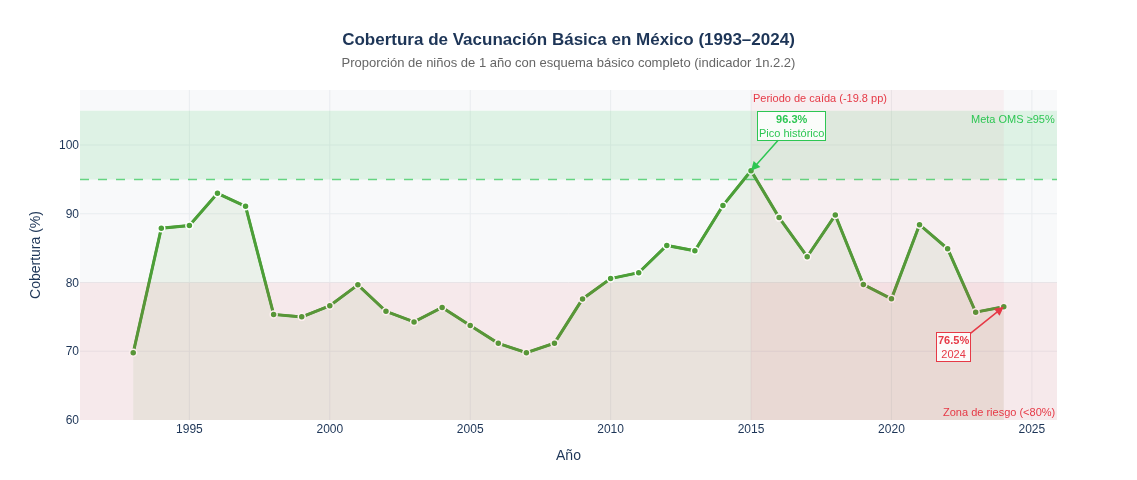

Caida total: 19.8 puntos porcentuales (2015 a 2024)
Anos por debajo de meta OMS (>=95%): 31 de 32


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Serie de tiempo: Cobertura de vacunación (1993–2024)
# ══════════════════════════════════════════════════════════════════════════════

vacc = get_serie('1N.2.2')

fig_vacc = go.Figure()

# Zona de meta OMS (≥95%)
fig_vacc.add_hrect(
    y0=95, y1=105,
    fillcolor='rgba(44,198,83,0.12)', line_width=0,
    annotation_text='Meta OMS ≥95%',
    annotation_position='top right',
    annotation_font=dict(color=COLOR_MEJORA, size=11)
)

# Zona de riesgo (<80%)
fig_vacc.add_hrect(
    y0=60, y1=80,
    fillcolor='rgba(230,57,70,0.08)', line_width=0,
    annotation_text='Zona de riesgo (<80%)',
    annotation_position='bottom right',
    annotation_font=dict(color=COLOR_ALERTA, size=11)
)

# Área rellena bajo la curva
fig_vacc.add_trace(go.Scatter(
    x=vacc['periodo'], y=vacc['valor'],
    fill='tozeroy', fillcolor='rgba(76,159,56,0.08)',
    line=dict(color=COLOR_ODS3, width=2.5),
    mode='lines', showlegend=False
))

# Línea principal con marcadores
fig_vacc.add_trace(go.Scatter(
    x=vacc['periodo'], y=vacc['valor'],
    mode='lines+markers',
    name='Cobertura de vacunación',
    line=dict(color=COLOR_ODS3, width=3),
    marker=dict(size=7, color=COLOR_ODS3, line=dict(width=1.5, color='white')),
    hovertemplate='<b>%{x}</b><br>Cobertura: <b>%{y:.1f}%</b><extra></extra>'
))

# Resaltar periodo de caída (2015–2024)
fig_vacc.add_vrect(
    x0=2015, x1=2024,
    fillcolor='rgba(230,57,70,0.05)', line_width=0,
    annotation_text='Periodo de caída (-19.8 pp)',
    annotation_position='top left',
    annotation_font=dict(color=COLOR_ALERTA, size=11)
)

# Anotación pico 2015
fig_vacc.add_annotation(
    x=2015, y=96.26, text='<b>96.3%</b><br>Pico histórico',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_MEJORA,
    arrowsize=1.2, arrowwidth=1.5, ax=40, ay=-45,
    font=dict(size=11, color=COLOR_MEJORA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=COLOR_MEJORA, borderwidth=1
)

# Anotación 2024
fig_vacc.add_annotation(
    x=2024, y=76.48, text='<b>76.5%</b><br>2024',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_ALERTA,
    arrowsize=1.2, arrowwidth=1.5, ax=-50, ay=40,
    font=dict(size=11, color=COLOR_ALERTA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=COLOR_ALERTA, borderwidth=1
)

fig_vacc.add_hline(
    y=95, line_dash='dash', line_color=COLOR_MEJORA, line_width=1.5, opacity=0.7
)

fig_vacc.update_layout(
    title=dict(
        text='<b>Cobertura de Vacunación Básica en México (1993–2024)</b><br>'
             '<span style="font-size:13px;font-weight:normal;color:#666">'
             'Proporción de niños de 1 año con esquema básico completo (indicador 1n.2.2)</span>',
        x=0.5, xanchor='center'
    ),
    xaxis=dict(title='Año', showgrid=True, gridcolor='#E9ECEF', dtick=5),
    yaxis=dict(title='Cobertura (%)', range=[60, 108], showgrid=True, gridcolor='#E9ECEF'),
    height=480,
    plot_bgcolor=COLOR_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color='#1D3557'),
    showlegend=False, margin=dict(t=90, b=60)
)

fig_vacc.show()
print(f'Caida total: {96.26 - 76.48:.1f} puntos porcentuales (2015 a 2024)')
print(f'Anos por debajo de meta OMS (>=95%): {len(vacc[vacc["valor"] < 95])} de {len(vacc)}')

---
## Alarma 2 — Las Enfermedades que Regresaron

El dengue, el chikungunya, el zika. México los había puesto bajo control.  
Pero en la última década, las **enfermedades transmitidas por vectores** explotaron.

De 34.8 casos por cada 100,000 habitantes en 2017 a **249.9 en 2024**.  
Un incremento de **+619% en solo 7 años**. No es un pico aislado — es una tendencia que se acelera.

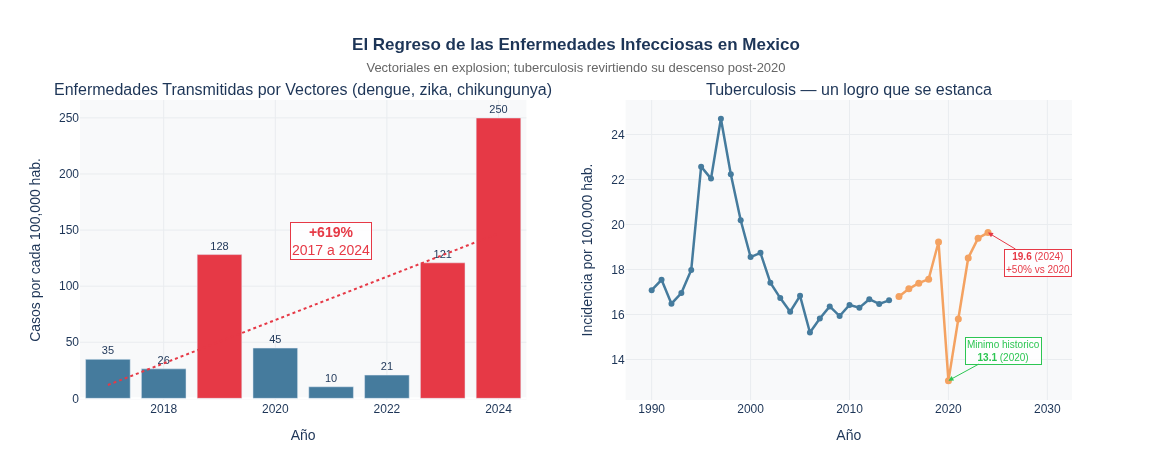

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 3 — Enfermedades vectoriales + Tuberculosis (panel doble)
# ══════════════════════════════════════════════════════════════════════════════

vector = get_serie('3R.3.C(1)')
tb     = get_serie('3.3.2A')

fig_inf = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Enfermedades Transmitidas por Vectores (dengue, zika, chikungunya)',
        'Tuberculosis — un logro que se estanca'
    ],
    horizontal_spacing=0.1
)

# ── Panel izquierdo: Vectoriales ──────────────────────────────────────────────
fig_inf.add_trace(go.Bar(
    x=vector['periodo'], y=vector['valor'],
    name='Enf. vectoriales',
    marker_color=[
        COLOR_ALERTA if v > 100 else COLOR_ACENTO if v > 50 else COLOR_NEUTRO
        for v in vector['valor']
    ],
    text=vector['valor'].round(0).astype(int),
    textposition='outside',
    textfont=dict(size=11, color='#1D3557'),
    hovertemplate='<b>%{x}</b><br>Incidencia: <b>%{y:.1f}</b> por 100k hab.<extra></extra>',
    showlegend=False
), row=1, col=1)

# Línea de tendencia
x_vec = np.array(vector['periodo'])
y_vec = np.array(vector['valor'])
m_vec, b_vec = np.polyfit(x_vec, y_vec, 1)
fig_inf.add_trace(go.Scatter(
    x=x_vec, y=m_vec * x_vec + b_vec,
    mode='lines', line=dict(color=COLOR_ALERTA, width=2, dash='dot'),
    showlegend=False, hoverinfo='skip'
), row=1, col=1)

fig_inf.add_annotation(
    x=2021, y=140, text='<b>+619%</b><br>2017 a 2024',
    showarrow=False, font=dict(size=14, color=COLOR_ALERTA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=COLOR_ALERTA, borderwidth=1,
    row=1, col=1
)

# ── Panel derecho: Tuberculosis ───────────────────────────────────────────────
tb_base   = tb[tb['periodo'] < 2015]
tb_recent = tb[tb['periodo'] >= 2015]

fig_inf.add_trace(go.Scatter(
    x=tb_base['periodo'], y=tb_base['valor'],
    mode='lines+markers', name='Tuberculosis (1990–2014)',
    line=dict(color=COLOR_NEUTRO, width=2.5),
    marker=dict(size=6, color=COLOR_NEUTRO),
    hovertemplate='<b>%{x}</b><br>Incidencia TB: <b>%{y:.1f}</b> por 100k<extra></extra>',
    showlegend=False
), row=1, col=2)

fig_inf.add_trace(go.Scatter(
    x=tb_recent['periodo'], y=tb_recent['valor'],
    mode='lines+markers', name='Subida post-2019',
    line=dict(color=COLOR_ACENTO, width=2.5),
    marker=dict(size=7, color=COLOR_ACENTO),
    hovertemplate='<b>%{x}</b><br>TB: <b>%{y:.1f}</b> por 100k<extra></extra>',
    showlegend=False
), row=1, col=2)

fig_inf.add_annotation(
    x=2020, y=13.06, text='Minimo historico<br><b>13.1</b> (2020)',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_MEJORA,
    ax=55, ay=-30, font=dict(size=10, color=COLOR_MEJORA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=COLOR_MEJORA, borderwidth=1,
    row=1, col=2
)
fig_inf.add_annotation(
    x=2024, y=19.64, text='<b>19.6</b> (2024)<br>+50% vs 2020',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_ALERTA,
    ax=50, ay=30, font=dict(size=10, color=COLOR_ALERTA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=COLOR_ALERTA, borderwidth=1,
    row=1, col=2
)

fig_inf.update_xaxes(showgrid=True, gridcolor='#E9ECEF', title_text='Año')
fig_inf.update_yaxes(showgrid=True, gridcolor='#E9ECEF')
fig_inf.update_yaxes(title_text='Casos por cada 100,000 hab.', row=1, col=1)
fig_inf.update_yaxes(title_text='Incidencia por 100,000 hab.', row=1, col=2)

fig_inf.update_layout(
    title=dict(
        text='<b>El Regreso de las Enfermedades Infecciosas en Mexico</b><br>'
             '<span style="font-size:13px;font-weight:normal;color:#666">'
             'Vectoriales en explosion; tuberculosis revirtiendo su descenso post-2020</span>',
        x=0.5, xanchor='center'
    ),
    height=460, plot_bgcolor=COLOR_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color='#1D3557'),
    showlegend=False, margin=dict(t=100, b=60)
)

fig_inf.show()

---
## Alarma 3 — La Epidemia Crónica que no Para

Las enfermedades cardiovasculares, el cáncer, la diabetes y las enfermedades respiratorias crónicas matan a **272 personas por cada 100,000 habitantes** en México (2024).

En 1998 eran 223. En 2020, el año del COVID, llegaron a **340** — su pico histórico.  
El sistema nunca se recuperó del todo.

Detrás está otra epidemia silenciosa: el **sobrepeso y la obesidad**, que afecta al **37% de la población** y no muestra señales de reversa.

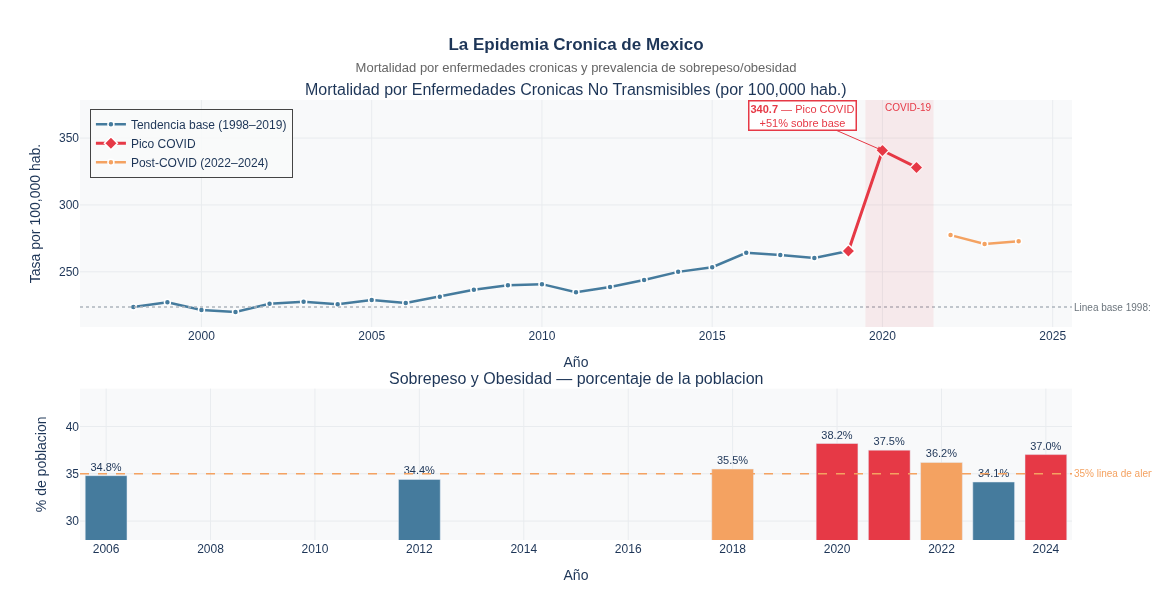

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 4 — Mortalidad crónica + Sobrepeso/Obesidad
# ══════════════════════════════════════════════════════════════════════════════

cron = get_serie('3.4.1')
obes = get_serie('3N.4.1A')

fig_cron = make_subplots(
    rows=2, cols=1,
    subplot_titles=[
        'Mortalidad por Enfermedades Cronicas No Transmisibles (por 100,000 hab.)',
        'Sobrepeso y Obesidad — porcentaje de la poblacion'
    ],
    vertical_spacing=0.14,
    row_heights=[0.6, 0.4]
)

# ── Panel superior: mortalidad crónica ────────────────────────────────────────
cron_pre  = cron[cron['periodo'] < 2020]
cron_cov  = cron[(cron['periodo'] >= 2019) & (cron['periodo'] <= 2021)]
cron_post = cron[cron['periodo'] > 2021]

fig_cron.add_trace(go.Scatter(
    x=cron_pre['periodo'], y=cron_pre['valor'],
    mode='lines+markers', name='Tendencia base (1998–2019)',
    line=dict(color=COLOR_NEUTRO, width=2.5),
    marker=dict(size=6, color=COLOR_NEUTRO, line=dict(width=1.5, color='white')),
    hovertemplate='<b>%{x}</b><br>Mortalidad: <b>%{y:.1f}</b> por 100k<extra></extra>'
), row=1, col=1)

fig_cron.add_trace(go.Scatter(
    x=cron_cov['periodo'], y=cron_cov['valor'],
    mode='lines+markers', name='Pico COVID',
    line=dict(color=COLOR_ALERTA, width=3),
    marker=dict(size=10, color=COLOR_ALERTA, symbol='diamond',
                line=dict(width=1.5, color='white')),
    hovertemplate='<b>%{x}</b><br>Mortalidad COVID: <b>%{y:.1f}</b> por 100k<extra></extra>'
), row=1, col=1)

fig_cron.add_trace(go.Scatter(
    x=cron_post['periodo'], y=cron_post['valor'],
    mode='lines+markers', name='Post-COVID (2022–2024)',
    line=dict(color=COLOR_ACENTO, width=2.5),
    marker=dict(size=6, color=COLOR_ACENTO, line=dict(width=1.5, color='white')),
    hovertemplate='<b>%{x}</b><br>Mortalidad: <b>%{y:.1f}</b> por 100k<extra></extra>'
), row=1, col=1)

fig_cron.add_hline(
    y=223.6, line_dash='dot', line_color='#ADB5BD', line_width=1.5,
    row=1, col=1,
    annotation_text='Linea base 1998: 223.6',
    annotation_position='right',
    annotation_font=dict(size=10, color='#6C757D')
)
fig_cron.add_vrect(
    x0=2019.5, x1=2021.5, fillcolor='rgba(230,57,70,0.08)', line_width=0,
    annotation_text='COVID-19', annotation_position='top right',
    annotation_font=dict(size=10, color=COLOR_ALERTA), row=1, col=1
)
fig_cron.add_annotation(
    x=2020, y=340.7, text='<b>340.7</b> — Pico COVID<br>+51% sobre base',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_ALERTA,
    ax=-80, ay=-35, font=dict(size=11, color=COLOR_ALERTA),
    bgcolor='rgba(255,255,255,0.9)', bordercolor=COLOR_ALERTA, borderwidth=1.5,
    row=1, col=1
)

# ── Panel inferior: sobrepeso ─────────────────────────────────────────────────
fig_cron.add_trace(go.Bar(
    x=obes['periodo'], y=obes['valor'],
    name='Sobrepeso y obesidad',
    marker_color=[
        COLOR_ALERTA if v >= 37 else COLOR_ACENTO if v >= 35 else COLOR_NEUTRO
        for v in obes['valor']
    ],
    text=[f'{v:.1f}%' for v in obes['valor']],
    textposition='outside', textfont=dict(size=11),
    hovertemplate='<b>%{x}</b><br>Prevalencia: <b>%{y:.1f}%</b><extra></extra>',
    showlegend=False
), row=2, col=1)

fig_cron.add_hline(
    y=35, line_dash='dash', line_color=COLOR_ACENTO, line_width=1.5,
    row=2, col=1,
    annotation_text='35% linea de alerta', annotation_position='right',
    annotation_font=dict(size=10, color=COLOR_ACENTO)
)

fig_cron.update_xaxes(showgrid=True, gridcolor='#E9ECEF', title_text='Año')
fig_cron.update_yaxes(showgrid=True, gridcolor='#E9ECEF')
fig_cron.update_yaxes(title_text='Tasa por 100,000 hab.', row=1, col=1)
fig_cron.update_yaxes(title_text='% de poblacion', row=2, col=1, range=[28, 44])

fig_cron.update_layout(
    title=dict(
        text='<b>La Epidemia Cronica de Mexico</b><br>'
             '<span style="font-size:13px;font-weight:normal;color:#666">'
             'Mortalidad por enfermedades cronicas y prevalencia de sobrepeso/obesidad</span>',
        x=0.5, xanchor='center'
    ),
    height=600, plot_bgcolor=COLOR_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color='#1D3557'),
    legend=dict(x=0.01, y=0.98, bgcolor='rgba(248,249,250,0.9)', borderwidth=1),
    margin=dict(t=100, b=60)
)

fig_cron.show()

---
## Alarma 4 — La Crisis de Salud Mental Invisible

La tasa de suicidio en México se **triplicó** en 30 años.  
De 2.29 por cada 100,000 habitantes en 1990 a **6.17 en 2020**.

Este indicador mide solo el extremo más visible de una crisis de salud mental que permanece profundamente subatendida. El ODS 3 establece metas explícitas sobre bienestar mental. México no las está cumpliendo.

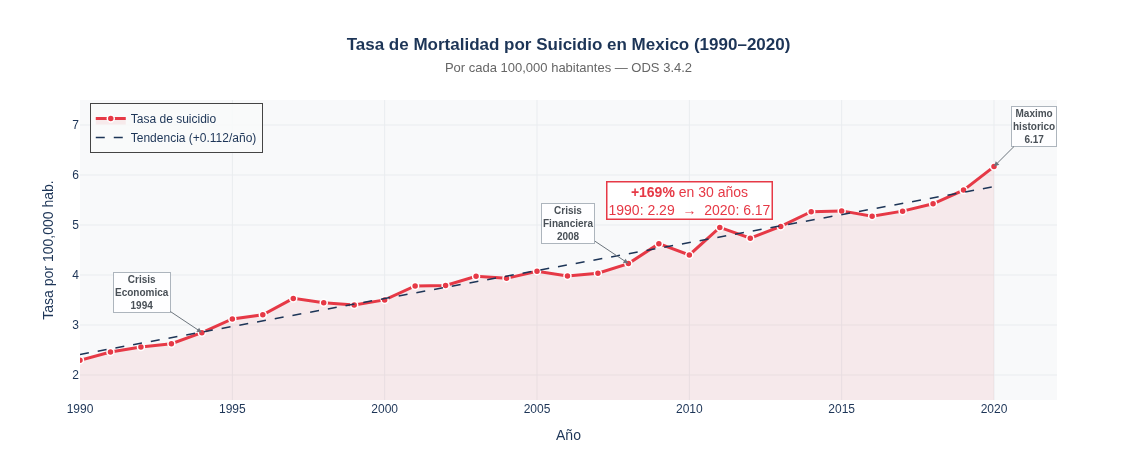

Pendiente de crecimiento: +0.112 casos/100k por año en promedio
Proyeccion 2030 (si continua tendencia): 6.89 por 100k


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 5 — Tasa de suicidio (1990–2020) con anotaciones narrativas
# ══════════════════════════════════════════════════════════════════════════════

suic = get_serie('3.4.2.A')

fig_suic = go.Figure()

fig_suic.add_trace(go.Scatter(
    x=suic['periodo'], y=suic['valor'],
    fill='tozeroy', fillcolor='rgba(230,57,70,0.08)',
    line=dict(color=COLOR_ALERTA, width=3),
    mode='lines+markers',
    marker=dict(size=7, color=COLOR_ALERTA, line=dict(width=1.5, color='white')),
    name='Tasa de suicidio',
    hovertemplate='<b>%{x}</b><br>Tasa: <b>%{y:.2f}</b> por 100,000 hab.<extra></extra>'
))

# Línea de tendencia lineal
x_s = np.array(suic['periodo'])
y_s = np.array(suic['valor'])
m_s, b_s = np.polyfit(x_s, y_s, 1)
fig_suic.add_trace(go.Scatter(
    x=x_s, y=m_s * x_s + b_s,
    mode='lines', name=f'Tendencia (+{m_s:.3f}/año)',
    line=dict(color='#1D3557', width=1.5, dash='dash'),
    hoverinfo='skip'
))

# Hitos de contexto socioeconómico
hitos = [
    (1994, 2.85, 'Crisis<br>Economica<br>1994', -60, -40),
    (2008, 4.23, 'Crisis<br>Financiera<br>2008', -60, -40),
    (2020, 6.17, 'Maximo<br>historico<br>6.17', 40, -40),
]
for año, val, txt, ax_, ay_ in hitos:
    fig_suic.add_annotation(
        x=año, y=val, text=f'<b>{txt}</b>',
        showarrow=True, arrowhead=2, arrowcolor='#6C757D',
        ax=ax_, ay=ay_, font=dict(size=10, color='#495057'),
        bgcolor='rgba(255,255,255,0.85)', bordercolor='#ADB5BD', borderwidth=1
    )

fig_suic.add_annotation(
    x=2010, y=5.5,
    text='<b>+169%</b> en 30 años<br>1990: 2.29  →  2020: 6.17',
    showarrow=False, font=dict(size=14, color=COLOR_ALERTA),
    bgcolor='rgba(255,255,255,0.9)', bordercolor=COLOR_ALERTA, borderwidth=1.5
)

fig_suic.update_layout(
    title=dict(
        text='<b>Tasa de Mortalidad por Suicidio en Mexico (1990–2020)</b><br>'
             '<span style="font-size:13px;font-weight:normal;color:#666">'
             'Por cada 100,000 habitantes — ODS 3.4.2</span>',
        x=0.5, xanchor='center'
    ),
    xaxis=dict(title='Año', showgrid=True, gridcolor='#E9ECEF', dtick=5),
    yaxis=dict(title='Tasa por 100,000 hab.', range=[1.5, 7.5],
               showgrid=True, gridcolor='#E9ECEF'),
    height=460, plot_bgcolor=COLOR_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color='#1D3557'),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(248,249,250,0.9)', borderwidth=1),
    margin=dict(t=100, b=60)
)

fig_suic.show()
print(f'Pendiente de crecimiento: +{m_s:.3f} casos/100k por año en promedio')
print(f'Proyeccion 2030 (si continua tendencia): {m_s * 2030 + b_s:.2f} por 100k')

---
## El Contrapeso — Lo que Si Mejoró

La narrativa honesta también muestra los avances. México sí tiene logros en salud pública que vale reconocer — para entender mejor **dónde se rompió el hilo**.

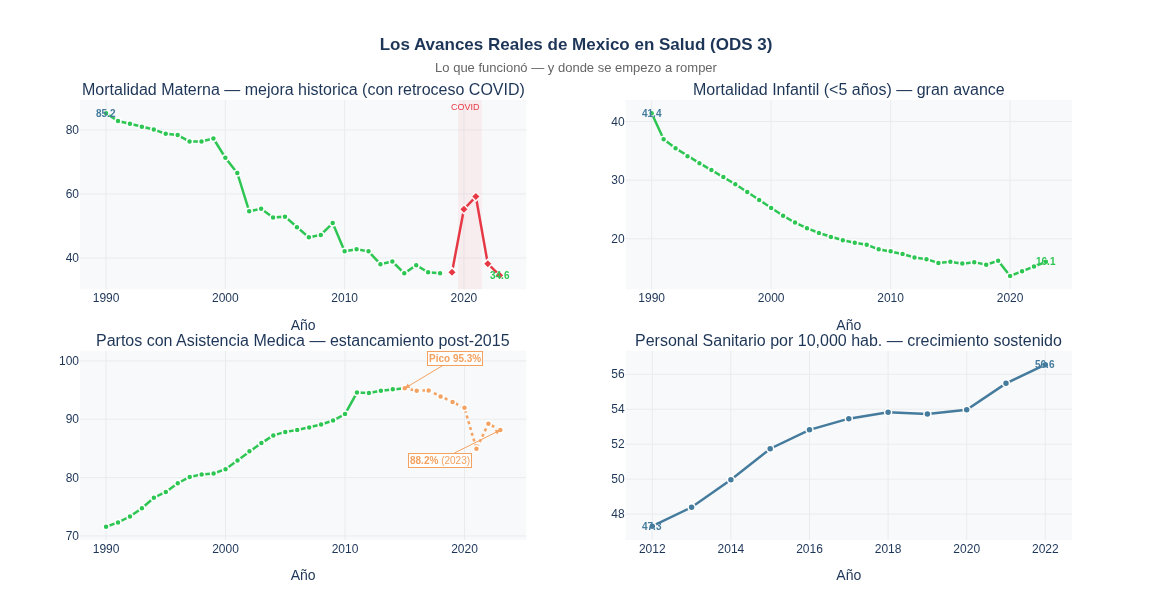

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 6 — Indicadores con mejora: mortalidad materna, infantil, partos, personal
# ══════════════════════════════════════════════════════════════════════════════

mat  = get_serie('3.1.1')
inf5 = get_serie('3.2.1')
part = get_serie('3.1.2')
pers = get_serie('3.C.1')

fig_bien = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Mortalidad Materna — mejora historica (con retroceso COVID)',
        'Mortalidad Infantil (<5 años) — gran avance',
        'Partos con Asistencia Medica — estancamiento post-2015',
        'Personal Sanitario por 10,000 hab. — crecimiento sostenido'
    ],
    vertical_spacing=0.14, horizontal_spacing=0.1
)

# Mortalidad materna
mat_base = mat[mat['periodo'] < 2019]
mat_cov  = mat[mat['periodo'] >= 2019]
fig_bien.add_trace(go.Scatter(
    x=mat_base['periodo'], y=mat_base['valor'],
    mode='lines+markers', line=dict(color=COLOR_MEJORA, width=2.5),
    marker=dict(size=6, color=COLOR_MEJORA, line=dict(width=1.5, color='white')),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>%{y:.1f} por 100k NV<extra></extra>'
), row=1, col=1)
fig_bien.add_trace(go.Scatter(
    x=mat_cov['periodo'], y=mat_cov['valor'],
    mode='lines+markers', line=dict(color=COLOR_ALERTA, width=2.5),
    marker=dict(size=7, color=COLOR_ALERTA, symbol='diamond',
                line=dict(width=1.5, color='white')),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>%{y:.1f} por 100k NV<extra></extra>'
), row=1, col=1)
fig_bien.add_vrect(x0=2019.5, x1=2021.5, fillcolor='rgba(230,57,70,0.06)',
                   line_width=0, row=1, col=1,
                   annotation_text='COVID', annotation_position='top right',
                   annotation_font=dict(size=9, color=COLOR_ALERTA))
fig_bien.add_annotation(x=1990, y=85.2, text='<b>85.2</b>',
                         showarrow=False, font=dict(size=10, color=COLOR_NEUTRO), row=1, col=1)
fig_bien.add_annotation(x=2023, y=34.6, text='<b>34.6</b>',
                         showarrow=False, font=dict(size=10, color=COLOR_MEJORA), row=1, col=1)

# Mortalidad infantil
fig_bien.add_trace(go.Scatter(
    x=inf5['periodo'], y=inf5['valor'],
    mode='lines+markers', line=dict(color=COLOR_MEJORA, width=2.5),
    marker=dict(size=6, color=COLOR_MEJORA, line=dict(width=1.5, color='white')),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>%{y:.1f} por 1,000 NV<extra></extra>'
), row=1, col=2)
fig_bien.add_annotation(x=1990, y=41.4, text='<b>41.4</b>',
                         showarrow=False, font=dict(size=10, color=COLOR_NEUTRO), row=1, col=2)
fig_bien.add_annotation(x=2023, y=16.1, text='<b>16.1</b>',
                         showarrow=False, font=dict(size=10, color=COLOR_MEJORA), row=1, col=2)

# Partos con asistencia
part_base_s = part[part['periodo'] <= 2015]
part_post_s = part[part['periodo'] >= 2015]
fig_bien.add_trace(go.Scatter(
    x=part_base_s['periodo'], y=part_base_s['valor'],
    mode='lines+markers', line=dict(color=COLOR_MEJORA, width=2.5),
    marker=dict(size=6, color=COLOR_MEJORA, line=dict(width=1.5, color='white')),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>%{y:.1f}%<extra></extra>'
), row=2, col=1)
fig_bien.add_trace(go.Scatter(
    x=part_post_s['periodo'], y=part_post_s['valor'],
    mode='lines+markers', line=dict(color=COLOR_ACENTO, width=2.5, dash='dot'),
    marker=dict(size=6, color=COLOR_ACENTO, line=dict(width=1.5, color='white')),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>%{y:.1f}%<extra></extra>'
), row=2, col=1)
fig_bien.add_annotation(
    x=2015, y=95.31, text='<b>Pico 95.3%</b>',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_ACENTO,
    ax=50, ay=-30, font=dict(size=10, color=COLOR_ACENTO),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=COLOR_ACENTO, borderwidth=1,
    row=2, col=1
)
fig_bien.add_annotation(
    x=2023, y=88.15, text='<b>88.2%</b> (2023)',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_ACENTO,
    ax=-60, ay=30, font=dict(size=10, color=COLOR_ACENTO),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=COLOR_ACENTO, borderwidth=1,
    row=2, col=1
)

# Personal sanitario
fig_bien.add_trace(go.Scatter(
    x=pers['periodo'], y=pers['valor'],
    mode='lines+markers', line=dict(color=COLOR_NEUTRO, width=2.5),
    marker=dict(size=7, color=COLOR_NEUTRO, line=dict(width=1.5, color='white')),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>%{y:.1f} por 10,000 hab.<extra></extra>'
), row=2, col=2)
fig_bien.add_annotation(x=2012, y=47.31, text='<b>47.3</b>',
                         showarrow=False, font=dict(size=10, color=COLOR_NEUTRO), row=2, col=2)
fig_bien.add_annotation(x=2022, y=56.55, text='<b>56.6</b>',
                         showarrow=False, font=dict(size=10, color=COLOR_NEUTRO), row=2, col=2)

fig_bien.update_xaxes(showgrid=True, gridcolor='#E9ECEF', title_text='Año')
fig_bien.update_yaxes(showgrid=True, gridcolor='#E9ECEF')

fig_bien.update_layout(
    title=dict(
        text='<b>Los Avances Reales de Mexico en Salud (ODS 3)</b><br>'
             '<span style="font-size:13px;font-weight:normal;color:#666">'
             'Lo que funcionó — y donde se empezo a romper</span>',
        x=0.5, xanchor='center'
    ),
    height=600, plot_bgcolor=COLOR_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color='#1D3557'),
    margin=dict(t=100, b=60)
)

fig_bien.show()

---
## El Sistema Interconectado — ODS 3 como Nodo Central

El ODS 3 no existe en aislamiento. Analizando los **1,285 pares de correlaciones** donde aparece, la salud está conectada — positiva o negativamente — con casi todos los demás ODS. El colapso silencioso de la salud pública **arrastra consigo** los avances en educación, empleo y paz social.

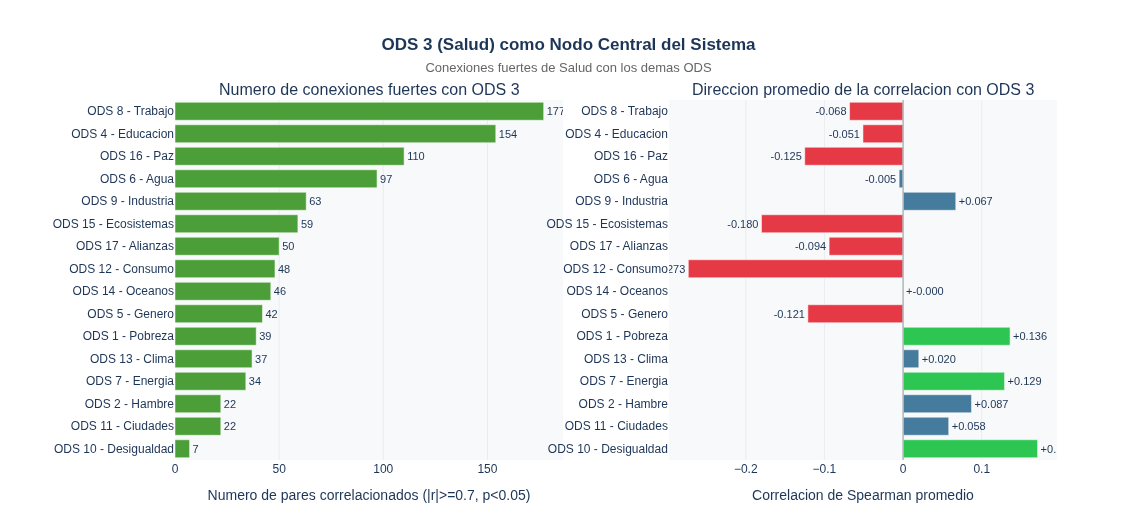

Total conexiones fuertes de ODS 3 con otros ODS: 1007
ODS mas conectado con ODS 3: ODS 8 - Trabajo - 177 pares


In [8]:

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 7 — Red de conexiones: ODS 3 como nodo central
# ══════════════════════════════════════════════════════════════════════════════

import ast

pares = pd.read_csv('../data/consolidated/pares_ods_correlaciones.csv')

# Parsear columna ods_pair de string "(3, 8)" a enteros
pares['pair_tuple'] = pares['ods_pair'].apply(ast.literal_eval)
pares['ods_1'] = pares['pair_tuple'].apply(lambda x: x[0])
pares['ods_2'] = pares['pair_tuple'].apply(lambda x: x[1])

# Filtrar pares que involucran ODS 3 (excluir el auto-par 3-3)
mask = ((pares['ods_1'] == 3) | (pares['ods_2'] == 3)) & \
       ~((pares['ods_1'] == 3) & (pares['ods_2'] == 3))
pares3 = pares[mask].copy()
pares3['otro_ods'] = pares3.apply(
    lambda r: r['ods_2'] if r['ods_1'] == 3 else r['ods_1'], axis=1
)
pares3 = pares3.sort_values('n_correlaciones', ascending=True)

ods_nombres = {
    1: 'ODS 1 - Pobreza',       2: 'ODS 2 - Hambre',
    4: 'ODS 4 - Educacion',     5: 'ODS 5 - Genero',
    6: 'ODS 6 - Agua',          7: 'ODS 7 - Energia',
    8: 'ODS 8 - Trabajo',       9: 'ODS 9 - Industria',
    10: 'ODS 10 - Desigualdad', 11: 'ODS 11 - Ciudades',
    12: 'ODS 12 - Consumo',     13: 'ODS 13 - Clima',
    14: 'ODS 14 - Oceanos',     15: 'ODS 15 - Ecosistemas',
    16: 'ODS 16 - Paz',         17: 'ODS 17 - Alianzas'
}
pares3['nombre'] = pares3['otro_ods'].map(ods_nombres).fillna(
    pares3['otro_ods'].apply(lambda x: 'ODS ' + str(x))
)
pares3['color_bar'] = pares3['corr_promedio'].apply(
    lambda c: COLOR_ALERTA if c < -0.05 else COLOR_MEJORA if c > 0.1 else COLOR_NEUTRO
)

fig_red = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Numero de conexiones fuertes con ODS 3',
        'Direccion promedio de la correlacion con ODS 3'
    ],
    horizontal_spacing=0.12
)

# Panel izq: número de conexiones
fig_red.add_trace(go.Bar(
    x=pares3['n_correlaciones'], y=pares3['nombre'],
    orientation='h', marker_color=COLOR_ODS3,
    marker_line_color='white', marker_line_width=0.5,
    text=pares3['n_correlaciones'], textposition='outside',
    textfont=dict(size=11),
    hovertemplate='<b>%{y}</b><br>Conexiones: <b>%{x}</b><extra></extra>',
    showlegend=False
), row=1, col=1)

# Panel der: correlación media
corr_vals = pares3['corr_promedio'].round(3)
fig_red.add_trace(go.Bar(
    x=corr_vals, y=pares3['nombre'],
    orientation='h', marker_color=pares3['color_bar'],
    marker_line_color='white', marker_line_width=0.5,
    text=['+{:.3f}'.format(c) if c >= 0 else '{:.3f}'.format(c) for c in corr_vals],
    textposition='outside', textfont=dict(size=11),
    hovertemplate='<b>%{y}</b><br>Correlacion media: <b>%{x:.3f}</b><extra></extra>',
    showlegend=False
), row=1, col=2)

fig_red.add_vline(x=0, line_width=1.5, line_color='#ADB5BD', row=1, col=2)

fig_red.update_xaxes(showgrid=True, gridcolor='#E9ECEF')
fig_red.update_yaxes(showgrid=False)
fig_red.update_xaxes(title_text='Numero de pares correlacionados (|r|>=0.7, p<0.05)', row=1, col=1)
fig_red.update_xaxes(title_text='Correlacion de Spearman promedio', row=1, col=2)

fig_red.update_layout(
    title=dict(
        text='<b>ODS 3 (Salud) como Nodo Central del Sistema</b><br>'
             '<span style="font-size:13px;font-weight:normal;color:#666">'
             'Conexiones fuertes de Salud con los demas ODS</span>',
        x=0.5, xanchor='center'
    ),
    height=520, plot_bgcolor=COLOR_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color='#1D3557'),
    margin=dict(t=100, b=60, l=175)
)

fig_red.show()
top = pares3.sort_values('n_correlaciones', ascending=False).iloc[0]
print('Total conexiones fuertes de ODS 3 con otros ODS:', pares3['n_correlaciones'].sum())
print('ODS mas conectado con ODS 3:', top['nombre'], '-', int(top['n_correlaciones']), 'pares')


---
## Sintesis Visual — El Radar de la Salud

Una mirada de conjunto: ¿dónde está México en cada dimensión del ODS 3?  
El radar compara el **valor actual** frente al **valor base (~2000)** y la **meta 2030**.

Score normalizado: **100 = meta cumplida** · **50 = punto de partida** · **<50 = retroceso**

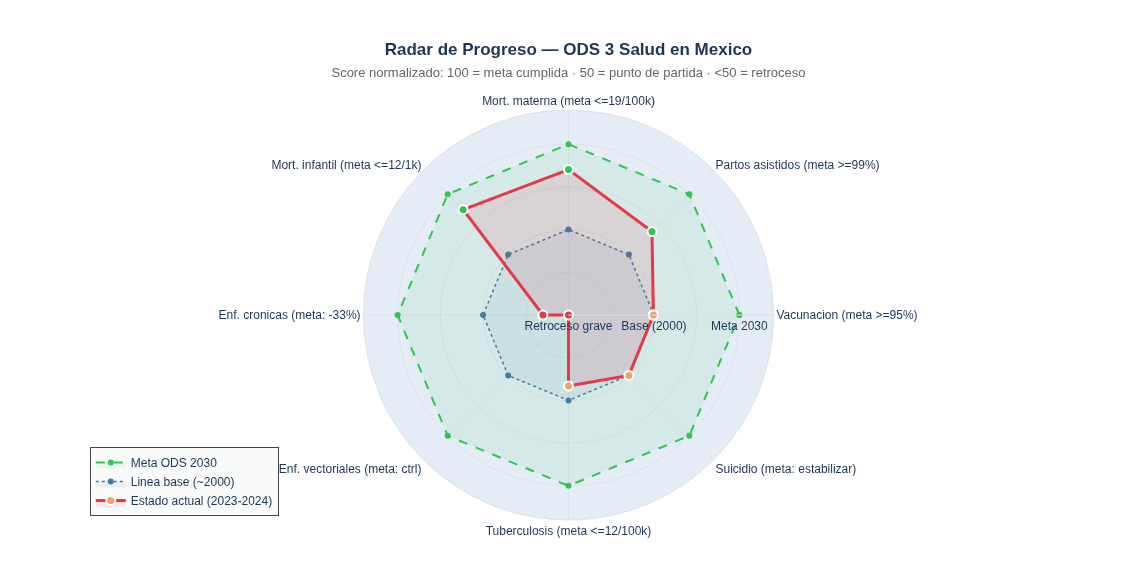


Scores de progreso ODS 3:
  ESTANCADO  Vacunacion                        49.7/100
  AVANZANDO  Partos asistidos                  69.1/100
  AVANZANDO  Mort. materna                     85.1/100
  AVANZANDO  Mort. infantil                    87.2/100
  RETROCESO  Enf. cronicas                     15.0/100
  RETROCESO  Enf. vectoriales                   0.0/100
  ESTANCADO  Tuberculosis                      41.5/100
  ESTANCADO  Suicidio                          50.0/100


In [9]:

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 8 — Radar: Estado actual vs meta 2030 en ODS 3
# ══════════════════════════════════════════════════════════════════════════════

radar_data = [
    # (etiqueta, base, actual, meta, mayor_mejor)
    ('Vacunacion\n(meta >=95%)',         76.6, 76.5,  95.0, True),
    ('Partos asistidos\n(meta >=99%)',   81.5, 88.2,  99.0, True),
    ('Mort. materna\n(meta <=19/100k)',  71.3, 34.6,  19.0, False),
    ('Mort. infantil\n(meta <=12/1k)',   28.0, 16.1,  12.0, False),
    ('Enf. cronicas\n(meta: -33%)',     221.5, 272.9, 148.0, False),
    ('Enf. vectoriales\n(meta: ctrl)',   50.0, 249.9,  20.0, False),
    ('Tuberculosis\n(meta <=12/100k)',   18.5, 19.6,  12.0, False),
    ('Suicidio\n(meta: estabilizar)',     3.5,  6.2,   3.5, False),
]

def normalizar(val, base, meta, mayor_mejor):
    if meta == base:
        return 50.0
    if mayor_mejor:
        score = (val - base) / (meta - base) * 50 + 50
    else:
        score = (base - val) / (base - meta) * 50 + 50
    return max(0.0, min(100.0, score))

categorias    = [d[0] for d in radar_data]
scores_actual = [round(normalizar(d[2], d[1], d[3], d[4]), 1) for d in radar_data]

cats_c   = categorias + [categorias[0]]
actual_c = scores_actual + [scores_actual[0]]
meta_c   = [100] * len(categorias) + [100]
base_c   = [50]  * len(categorias) + [50]

fig_radar = go.Figure()

fig_radar.add_trace(go.Scatterpolar(
    r=meta_c, theta=cats_c,
    fill='toself', fillcolor='rgba(44,198,83,0.08)',
    line=dict(color=COLOR_MEJORA, width=2, dash='dash'),
    name='Meta ODS 2030'
))
fig_radar.add_trace(go.Scatterpolar(
    r=base_c, theta=cats_c,
    fill='toself', fillcolor='rgba(69,123,157,0.08)',
    line=dict(color=COLOR_NEUTRO, width=1.5, dash='dot'),
    name='Linea base (~2000)'
))

colors_pts = [
    COLOR_ALERTA if s < 40 else COLOR_ACENTO if s < 65 else COLOR_MEJORA
    for s in scores_actual
]
fig_radar.add_trace(go.Scatterpolar(
    r=actual_c, theta=cats_c,
    fill='toself', fillcolor='rgba(230,57,70,0.12)',
    line=dict(color=COLOR_ALERTA, width=3),
    mode='lines+markers',
    marker=dict(size=9, color=colors_pts + [colors_pts[0]],
                line=dict(width=2, color='white')),
    name='Estado actual (2023-2024)',
    hovertemplate='<b>%{theta}</b><br>Score: <b>%{r:.0f}/100</b><extra></extra>'
))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True, range=[0, 120],
            tickvals=[0, 25, 50, 75, 100],
            ticktext=['Retroceso\ngrave', '', 'Base\n(2000)', '', 'Meta\n2030'],
            gridcolor='#DEE2E6', linecolor='#DEE2E6',
        ),
        angularaxis=dict(linecolor='#DEE2E6', gridcolor='#DEE2E6')
    ),
    title=dict(
        text='<b>Radar de Progreso — ODS 3 Salud en Mexico</b><br>'
             '<span style="font-size:13px;font-weight:normal;color:#666">'
             'Score normalizado: 100 = meta cumplida · 50 = punto de partida · <50 = retroceso</span>',
        x=0.5, xanchor='center'
    ),
    height=580, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color='#1D3557'),
    legend=dict(x=0.01, y=0.01, bgcolor='rgba(248,249,250,0.9)', borderwidth=1),
    margin=dict(t=110, b=60)
)

fig_radar.show()

print('\nScores de progreso ODS 3:')
for cat, score in zip(categorias, scores_actual):
    status = 'RETROCESO' if score < 40 else 'ESTANCADO' if score < 65 else 'AVANZANDO'
    print('  {:<10s} {:<32s} {:5.1f}/100'.format(status, cat.split('\n')[0], score))


---
## Conclusiones — El Diagnostico

### Lo que los datos revelan sobre la salud pública de México

---

**1. El retroceso en vacunación es la señal de alarma más crítica.**  
Caer de 96.3% a 76.5% en nueve años erosiona el escudo más efectivo de salud pública. Las consecuencias se verán en brotes de enfermedades prevenibles.

**2. Las enfermedades vectoriales son el riesgo emergente más urgente.**  
+619% en 7 años señala que el cambio climático, la urbanización y el deterioro de programas de control vectorial están convergiendo en una tormenta perfecta.

**3. La epidemia crónica (diabetes, cardiovascular, cáncer) es estructural.**  
No se resuelve con campañas. El 37% de obesidad es el combustible de esta epidemia y requiere transformar el entorno alimentario desde la raíz.

**4. La salud mental es el ODS 3 ignorado.**  
La tasa de suicidio triplicada en 30 años es la punta del iceberg de un sistema de salud mental notoriamente subfinanciado.

**5. El sistema sí puede mejorar — cuando se lo propone.**  
Mortalidad materna -59%, infantil -61%, personal sanitario creciendo. El problema no es de capacidad nacional, sino de **prioridades de inversión y continuidad de políticas**.

---

### ¿Qué necesita México para cumplir el ODS 3 en 2030?

| Prioridad | Acción concreta |
|-----------|----------------|
| **Inmediata** | Recuperar cobertura de vacunación al 95%+ con campaña nacional de reactivación |
| **Urgente** | Implementar programa nacional de control vectorial ante explosión de casos |
| **Estructural** | Reformar entorno alimentario: etiquetado, impuesto a ultraprocesados, espacios activos |
| **Pendiente** | Crear infraestructura de salud mental accesible a nivel de atención primaria |
| **Sistemica** | Fortalecer el monitoreo — muchos indicadores ODS tienen solo 4–5 datos en toda su serie |

---

*Análisis basado en 37 indicadores ODS 3 de México · INEGI 2026 · HackODS 2026*  
*Método: correlaciones Spearman, tendencias lineales, normalización por metas ODS 2030*